In [1]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

In [2]:
!pip -q install lightning torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.5/828.5 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 49.3 MB/s eta 0:00:00


# **실습 3 : Inception V3 Model Fine Tuning**

## **Import Module**

In [3]:
import torch
from torch import nn
from torch.nn import functional as F
from torchmetrics import functional as FM
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
import torchvision
from torchinfo import summary

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

from PIL import Image
from IPython import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

device ='cuda:0'
torch.__version__,L.__version__
# ('2.8.0+cu126', '2.5.5') 2510

('2.8.0+cu126', '2.5.5')

## **Dataset Load**

In [4]:
from torchvision.datasets.utils import download_and_extract_archive
import pathlib

dataset_url = \
      "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
root = './'
data_dir='Dataset'
download_and_extract_archive(dataset_url, root, data_dir)
data_dir = root+data_dir+'/flower_photos/'
data_dir = pathlib.Path(data_dir)
data_dir

100%|██████████| 229M/229M [00:09<00:00, 24.3MB/s]


PosixPath('Dataset/flower_photos')

In [5]:
!ls {data_dir}

daisy  dandelion  LICENSE.txt  roses  sunflowers  tulips


In [6]:
# 지정 폴더 아래에 있는 모든 *.jpg 파일의 수
#  및 폴더명 목록을 리턴
def check_dir(d_path):
    img_count = len(list(d_path.glob('*/*.jpg')))
    c_name = np.array([item.name for item in d_path.glob('*') if item.name != "LICENSE.txt"])
    return img_count, c_name, len(c_name)

# check_dir()로 폴더명과 이미지 숫자 확인
image_count, CLASS_name, class_num = check_dir(data_dir)
CLASS_name.sort()
print('Train image_count: {}\nclasses: {}'.format(image_count, CLASS_name))

Train image_count: 3670
classes: ['daisy' 'dandelion' 'roses' 'sunflowers' 'tulips']


In [7]:
# 지정 path 아래에 있는 폴더에서 이미지 두장씩을 확인
def check_image(d_path, class_list):
    for i in range(len(class_list)):
        class_temp = list(d_path.glob(str(class_list[i])+'/*'))
        for image_path in class_temp[:2]:
            display.display(Image.open(str(image_path)))
# check_image()로 이미지 두장씩 확인
check_image(data_dir, CLASS_name)

Output hidden; open in https://colab.research.google.com to view.

#### ImageFolder, DataLoader 적용

In [8]:
### Imagae size 결정 ###
IN_IMG_SIZE = 299
batch_n = 32

In [9]:
from torchvision.transforms.autoaugment import AutoAugment
from torchvision.datasets import ImageFolder

## loader에 적용할 transform
_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize((IN_IMG_SIZE, IN_IMG_SIZE)),
    v2.RandomResizedCrop(IN_IMG_SIZE, scale=[0.8, 1.2], ratio=[0.75,1.33],antialias=True ),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) ])

## ImageFolder : folder로 구성된 image set을 위한 loader
imgs = ImageFolder(data_dir, transform=_transforms) #(image,label)

len(imgs)

3670

##### Train / Test Data split

In [10]:
train_set_size = int(len(imgs) * 0.7)
valid_set_size = len(imgs) - train_set_size

# split the train set into two
train_set, valid_set = random_split(imgs, [train_set_size, valid_set_size])

print(train_set_size,valid_set_size)

2569 1101


In [11]:
## DataLoader : dataset과 sampler를 결합 batch단위 제공 #(image,label)*batch
train_loader = DataLoader(train_set, batch_size=batch_n, shuffle=True,num_workers=4)
val_loader = DataLoader(valid_set, batch_size=batch_n, shuffle=False,num_workers=4)

In [13]:
import os
os.cpu_count() # T4:2 or 8

8

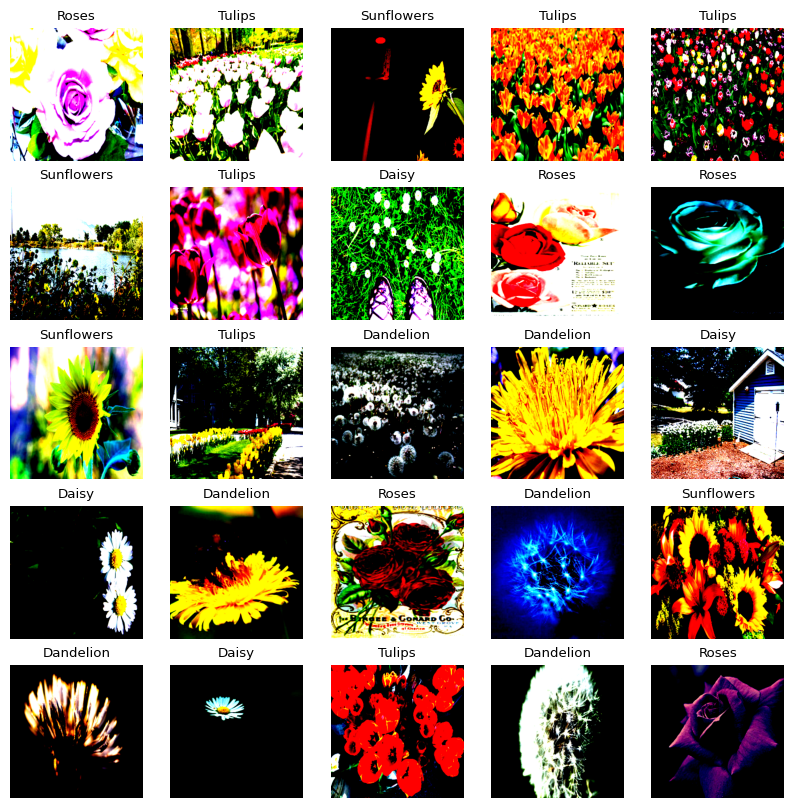

In [14]:
def show_batch(data_gen, class_l):
    # get image and label from data generator
    img_batch, l_batch = next(iter(data_gen))
    plt.figure(figsize=(10,10))
    for n in range(25):
        ax = plt.subplot(5,5,n+1)
        plt.imshow(img_batch[n].permute(1, 2, 0))
        plt.title(class_l[l_batch[n]].title())
        plt.axis('off')
    return img_batch, l_batch

# check dataset
_,_ = show_batch(train_loader, CLASS_name)
#_,_ = show_batch(vla_loader, CLASS_test)

## **Load InceptionV3 model**
https://pytorch.org/hub/pytorch_vision_inception_v3/

In [15]:
InceptionV3 = torch.hub.load('pytorch/vision', 'inception_v3', pretrained=True)

Downloading: "https://github.com/pytorch/vision/zipball/main" to /root/.cache/torch/hub/main.zip


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 259MB/s] 


In [16]:
input_shape=(batch_n, 3, IN_IMG_SIZE, IN_IMG_SIZE)
summary(InceptionV3, input_size=input_shape)

Layer (type:depth-idx)                   Output Shape              Param #
Inception3                               [32, 1000]                3,326,696
├─BasicConv2d: 1-1                       [32, 32, 149, 149]        --
│    └─Conv2d: 2-1                       [32, 32, 149, 149]        864
│    └─BatchNorm2d: 2-2                  [32, 32, 149, 149]        64
├─BasicConv2d: 1-2                       [32, 32, 147, 147]        --
│    └─Conv2d: 2-3                       [32, 32, 147, 147]        9,216
│    └─BatchNorm2d: 2-4                  [32, 32, 147, 147]        64
├─BasicConv2d: 1-3                       [32, 64, 147, 147]        --
│    └─Conv2d: 2-5                       [32, 64, 147, 147]        18,432
│    └─BatchNorm2d: 2-6                  [32, 64, 147, 147]        128
├─MaxPool2d: 1-4                         [32, 64, 73, 73]          --
├─BasicConv2d: 1-5                       [32, 80, 73, 73]          --
│    └─Conv2d: 2-7                       [32, 80, 73, 73]          5,

In [17]:
InceptionV3

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [18]:
InceptionV3.fc = nn.Sequential(
#                            nn.Linear(2048,512),
#                            nn.Dropout(0.5),
                            nn.Linear(2048, class_num)
                          )
InceptionV3

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [ ]:
#torch.onnx.export(InceptionV3, torch.zeros(batch_n, 3, IN_IMG_SIZE, IN_IMG_SIZE).to(device), 'inceptionV3.onnx')

### **마지막 `Inception module`만 남기고 나머지는 전부 freeze**
- ### 마지막 conv layer가 fine tuning 됨


In [19]:
for i, (name,child_module) in enumerate(InceptionV3.named_children()):
  if name == 'Mixed_7c':
    break
  else :
    print(i,':',name,'freezed')
    for param in child_module.parameters():
            param.requires_grad = False

0 : Conv2d_1a_3x3 freezed
1 : Conv2d_2a_3x3 freezed
2 : Conv2d_2b_3x3 freezed
3 : maxpool1 freezed
4 : Conv2d_3b_1x1 freezed
5 : Conv2d_4a_3x3 freezed
6 : maxpool2 freezed
7 : Mixed_5b freezed
8 : Mixed_5c freezed
9 : Mixed_5d freezed
10 : Mixed_6a freezed
11 : Mixed_6b freezed
12 : Mixed_6c freezed
13 : Mixed_6d freezed
14 : Mixed_6e freezed
15 : AuxLogits freezed
16 : Mixed_7a freezed
17 : Mixed_7b freezed


In [20]:
for child in InceptionV3.children():
    for param in child.parameters():
        print(child.__class__, param.requires_grad)
        break

<class 'torchvision.models.inception.BasicConv2d'> False
<class 'torchvision.models.inception.BasicConv2d'> False
<class 'torchvision.models.inception.BasicConv2d'> False
<class 'torchvision.models.inception.BasicConv2d'> False
<class 'torchvision.models.inception.BasicConv2d'> False
<class 'torchvision.models.inception.InceptionA'> False
<class 'torchvision.models.inception.InceptionA'> False
<class 'torchvision.models.inception.InceptionA'> False
<class 'torchvision.models.inception.InceptionB'> False
<class 'torchvision.models.inception.InceptionC'> False
<class 'torchvision.models.inception.InceptionC'> False
<class 'torchvision.models.inception.InceptionC'> False
<class 'torchvision.models.inception.InceptionC'> False
<class 'torchvision.models.inception.InceptionAux'> False
<class 'torchvision.models.inception.InceptionD'> False
<class 'torchvision.models.inception.InceptionE'> False
<class 'torchvision.models.inception.InceptionE'> True
<class 'torch.nn.modules.container.Sequent

## FineTune Model

In [21]:
###
lr=0.0001
Y = 0.0
class InceptionFineTune(L.LightningModule):
    def __init__(self, inceptionv3):
        super(InceptionFineTune, self).__init__()
        self.features = inceptionv3

    def forward(self, x):
        x = self.features(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        ## 주의: InceptionOutputs은 결과 tensor값을 .logits 으로 가짐
        loss = F.cross_entropy(y_pred.logits, y)

        acc = FM.accuracy(y_pred.logits, y, task='multiclass', num_classes=5)
        metrics={'loss':loss, 'acc':acc}
        self.log_dict(metrics,prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)

        acc = FM.accuracy(y_pred, y, task='multiclass', num_classes=5)
        metrics = {'val_loss':loss, 'val_acc':acc}
        self.log_dict(metrics, prog_bar=True, on_step=False, on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=lr) ###

inceptionFineTune = InceptionFineTune(InceptionV3)
summary(inceptionFineTune, input_size=(batch_n, 3, IN_IMG_SIZE, IN_IMG_SIZE))

Layer (type:depth-idx)                   Output Shape              Param #
InceptionFineTune                        [32, 5]                   --
├─Inception3: 1-1                        [32, 5]                   3,326,696
│    └─BasicConv2d: 2-1                  [32, 32, 149, 149]        --
│    │    └─Conv2d: 3-1                  [32, 32, 149, 149]        (864)
│    │    └─BatchNorm2d: 3-2             [32, 32, 149, 149]        (64)
│    └─BasicConv2d: 2-2                  [32, 32, 147, 147]        --
│    │    └─Conv2d: 3-3                  [32, 32, 147, 147]        (9,216)
│    │    └─BatchNorm2d: 3-4             [32, 32, 147, 147]        (64)
│    └─BasicConv2d: 2-3                  [32, 64, 147, 147]        --
│    │    └─Conv2d: 3-5                  [32, 64, 147, 147]        (18,432)
│    │    └─BatchNorm2d: 3-6             [32, 64, 147, 147]        (128)
│    └─MaxPool2d: 2-4                    [32, 64, 73, 73]          --
│    └─BasicConv2d: 2-5                  [32, 80, 73, 73]

## **Fit**

In [22]:
%%time
inceptionFineTune = InceptionFineTune(InceptionV3)
model_name = "InceptionFineTune"
epochs= 5 #20
logger = CSVLogger("logs", name=model_name)
trainer = Trainer(max_epochs=epochs, logger=logger)
trainer.fit(inceptionFineTune, train_loader, val_dataloaders=val_loader)
# Wall time: 1min 35s @ 5e
# Wall time: 5min 49s @ 20e

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name     | Type     

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=5` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


CPU times: user 1min 19s, sys: 5.94 s, total: 1min 25s
Wall time: 1min 29s


## **Analysis**

In [23]:
v_num = logger.version
history = pd.read_csv(f'./logs/{model_name}/version_{v_num}/metrics.csv')

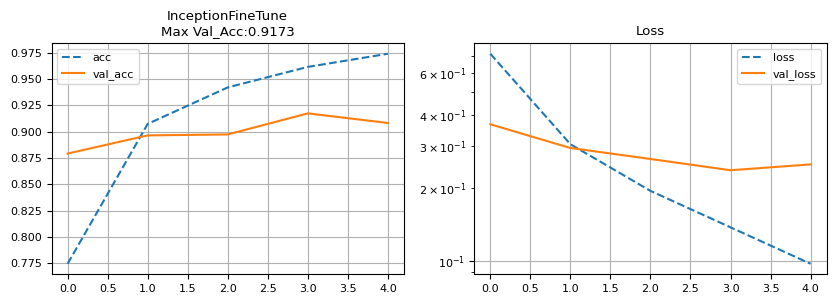

In [24]:
h1 = history.drop('step', axis=1).groupby('epoch').last()
max_ = h1['val_acc'].max()

plt.figure(figsize=(10,3))
title = model_name
plt.subplot(121)
plt.title(f"{title}\nMax Val_Acc:{max_:.4f}")
plt.plot(h1['acc'],'--', label='acc')
plt.plot(h1['val_acc'], label='val_acc')
#plt.ylim(0.7, 1)
plt.legend()
plt.grid()

plt.subplot(122)
plt.title("Loss")
plt.plot(h1['loss'],'--', label='loss')
plt.plot(h1['val_loss'], label='val_loss')
plt.semilogy()
plt.legend()
plt.grid()
plt.show()

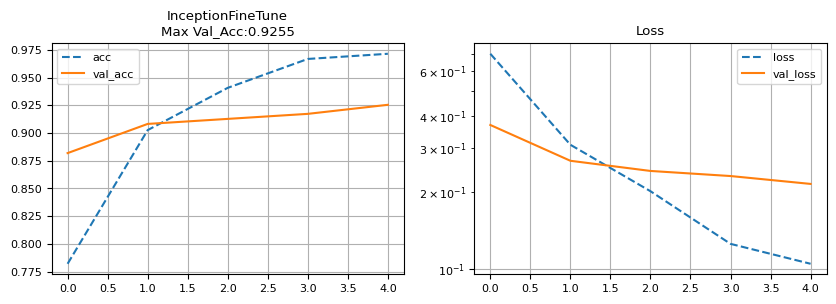

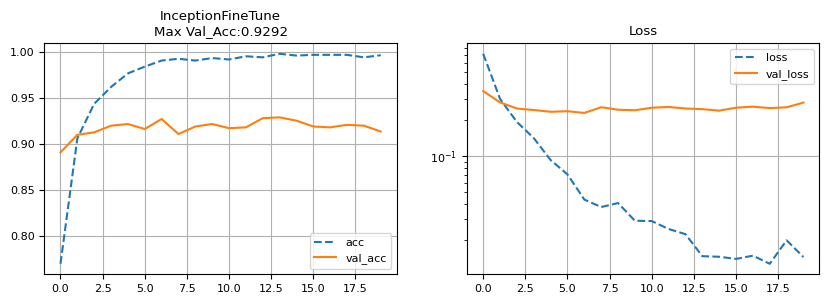

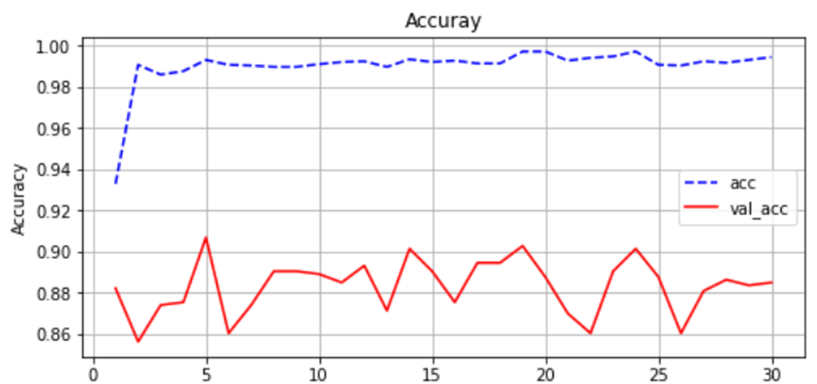

```python
InceptionV3.fc = nn.Sequential(
                            nn.Linear(2048,512),
                            nn.Dropout(0.5),
                            nn.Linear(512, class_num)
                          )
```

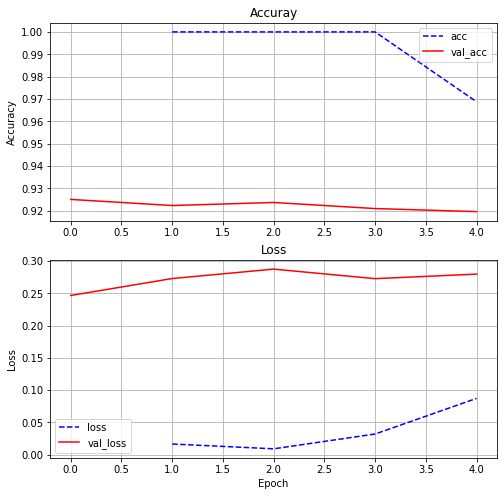

## **실습 과제**

### **마지막 inception module을 학습하도록 남겨놓을 필요가 있을까?**
#### -- 마지막까지 freeze한 경우에 성능은 어떨까 학인해 보자
#### -- 모델전체를 freeze하지 않고 학습시키면 어떤 결과를 얻을 수 있를까 확인해 보자  
#### -- fc추가 레이어를 좀더 추가하려면 어떻게 해야할까?
> BatchNorm, ReLU 레이어를 추가해 보자  
#### -- avgpool layer를 제거하려면 어떻게 해야 할까? 성능에 영향이 있을까?
